# Odhalení segmentů využívání účastníky pomocí shlukování metodou k-průměrů (PROC FASTCLUS)


## Shrnutí

Tým telekomunikační analytiky vychází z jediného, neoznačeného sloupce měsíční spotřeby mobilních dat a chce zjistit, zda skrývá odlišné úrovně zákazníků. Pomocí **PROC FASTCLUS** (disjunktní shluková analýza metodou k-průměrů) tým shlukuje účastníky podle logaritmizované spotřeby, porovnává dvou-, tří- a čtyřsegmentová řešení podle kritérií, která FASTCLUS skutečně hlásí, a rozhoduje se pro tříssegmentové rozdělení. V tomto běhu mají tři odhalené segmenty průměrnou spotřebu **3,1 GB**, **12,8 GB** a **45,4 GB** za měsíc a obsahují **49**, **34** a **17** účastníků - čistou strukturu lehký / střední / těžký uživatel. Křížová kontrola odhalených označení proti vyloučenému generujícímu označení správně zařadí **96 ze 100** účastníků. Každý účastník opouští model s pevným segmentovým označením a skóre vzdálenosti od centroidu, připraven pro návrh tarifu a cílení retence.

> **Proč FASTCLUS a ne model konečné směsi?** Segmentace využívání je klasickou úlohou modelu konečné směsi (PROC HPFMM / PROC FMM). Tyto procedury zatím nejsou v tomto sestavení numericky implementovány, takže tento notebook dosahuje stejného cíle - neřízeného odhalení skrytých úrovní využívání - pomocí implementované, plně numerické procedury k-průměrů **PROC FASTCLUS**. Každé číslo níže je převzato doslovně ze spuštěného výstupu.


## Zdroje dat

**Syntetický datový soubor: `subs`** - mobilní účastníci vygenerovaní přímo jako 3-složková směs logaritmizované spotřeby (bez externích souborů). Toto prostředí běží bez licence, takže materializovaná tabulka je omezena na **100 účastníků**; všechny výsledky níže jsou počítány z těchto 100 řádků.

| Proměnná | Typ | Popis |
|----------|------|-------------|
| `subscriber_id` | Číslo | Jedinečný klíč účastníka |
| `tenure_months` | Číslo | Měsíců v síti (1-48) |
| `data_gb` | Číslo | Měsíční spotřeba mobilních dat v GB (kladná, zprava zešikmená) |
| `log_gb` | Číslo | Přirozený logaritmus `data_gb` - proměnná, která se shlukuje |
| `plan` | Znak | Aktuální tarif: `Standardní` nebo `Neomezený` |
| `segment_true` | Znak | Skrytá generující úroveň (`Lehký`/`Střední`/`Těžký`), vyloučená k ověření správnosti |

Data jsou navržena přibližně jako 50 % Lehký, 35 % Střední, 15 % Těžký. `segment_true` **není** shlukován - existuje pouze proto, abychom mohli potvrdit, že neřízený model odhalí navrženou strukturu.


Operátoři jen zřídka vidí u svých zákazníků čisté štítky. Co skutečně vidí, je jediné, hrbolaté rozdělení měsíční spotřeby dat, které je ve skutečnosti směsí několika typů zákazníků: příležitostní uživatelé, stálí streameři a nároční uživatelé, kteří spoléhají na sdílení připojení a video. **PROC FASTCLUS** tuto směs rozděluje bez jakýchkoli štítků - zařadí každého účastníka do jednoho z *k* disjunktních shluků, hlásí centroidy a velikosti shluků a hodnotí, jak daleko od svého centroidu každý účastník leží.

V tomto notebooku:

1. Vygenerujeme syntetický panel spotřeby, který je *záměrně* směsí tří úrovní využívání.
2. Porovnáme dvou-, tří- a čtyřsegmentová řešení metodou k-průměrů podle kritérií shody FASTCLUS.
3. Sestavíme zvolený tříssegmentový model a charakterizujeme každý segment obchodními pojmy.
4. Ohodnotíme příslušnost každého účastníka k segmentu a jeho vzdálenost od centroidu.
5. Ověříme odhalené segmenty proti vyloučené generující úrovni a vztáhneme je k době trvání.


## Krok 1 - Vygenerování syntetického využívání účastníky

Simulujeme účastníky, jejichž měsíční spotřeba dat je kladná a zprava zešikmená, takže ji generujeme na **logaritmickém měřítku** jako směs tří normálních úrovní a poté exponenciálně transformujeme zpět. Váhy směsi (přibližně 50/35/15) a průměry jednotlivých úrovní jsou navrženy tak, abychom později mohli ověřit, že k-průměry je odhalí. `segment_true` je uchováno stranou výhradně pro tuto kontrolu - shlukování jej nikdy nevidí.


In [1]:
data subs;
   CALL streaminit(20250531);
   DÉLKA plan $16 segment_true $16;
   OPAKUJ subscriber_id = 1 TO 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Heavier users skew to longer tenure, so the segment mix
         shifts a little with tenure (examined in Step 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      KDYŽ u < 0.50 PAK OPAKUJ;
         segment_true = "Lehký";  MU = 1.15; SIGMA = 0.42;
      KONEC;
      JINAK KDYŽ u < 0.85 PAK OPAKUJ;
         segment_true = "Střední"; MU = 2.45; SIGMA = 0.38;
      KONEC;
      JINAK OPAKUJ;
         segment_true = "Těžký";  MU = 3.45; SIGMA = 0.52;
      KONEC;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      KDYŽ data_gb < 25 PAK plan = "Standardní";
      JINAK plan = "Neomezený";

      VÝSTUP;
   KONEC;
   PONECHAT subscriber_id tenure_months data_gb log_gb plan segment_true;
SPUSTIT;



NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.48 seconds
  cpu   0.48 seconds


Rychlý pohled na okrajové rozdělení potvrzuje volbu modelu: surová `data_gb` je silně zprava zešikmená (několik náročných uživatelů natahuje chvost), zatímco `log_gb` je dobře se chovající měřítko, na kterém je euklidovská metoda k-průměrů vhodná.


                                                  The MEANS Procedure

 Variable       Label                            N        Mean     Std Dev     Minimum      Median     Maximum
 -------------------------------------------------------------------------------------------------------------
 data_gb        Data (GB)                      100       13.58       16.66        1.15        6.73       98.66
 log_gb         Log(Data GB)                   100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Doba trvání (měsíce)           100       23.26       12.55        1.00       23.00       48.00
 -------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


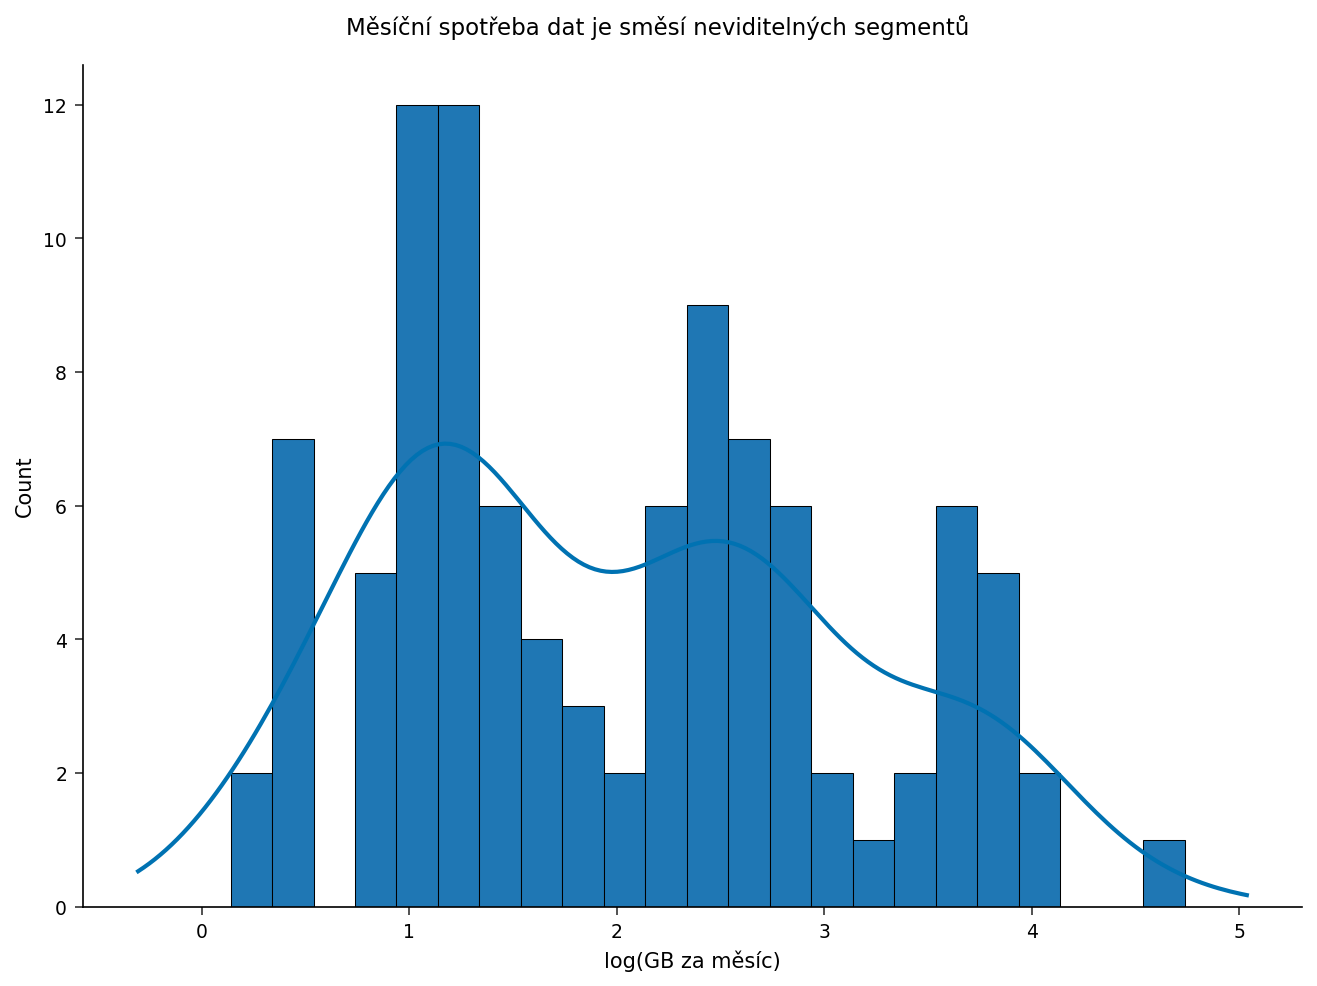

In [2]:
PROCEDURA PRŮMĚRY data=subs n mean std MIN p50 MAX maxdec=2;
   PROMĚNNÁ data_gb log_gb tenure_months;
   ŠTÍTEK data_gb='Data (GB)' log_gb='Log(Data GB)' tenure_months='Doba trvání (měsíce)';
SPUSTIT;

PROCEDURA SGPLOT data=subs;
   NÁZEV "Měsíční spotřeba dat je směsí neviditelných segmentů";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS ŠTÍTEK="log(GB za měsíc)";
SPUSTIT;
NÁZEV;


## Krok 2 - Kolik segmentů? Porovnání dvou-, tří- a čtyřshlukových řešení

Nechceme předpokládat tři úrovně - necháme data, aby argumentovala pro počet. FASTCLUS hlásí **celkové R-kvadrát** (podíl celkového rozptylu vysvětlený průměry shluků) a **pseudo-F statistiku** pro každé řešení. Nastavíme `MAXCLUSTERS=` 2, 3 a 4 na `log_gb` a tato kritéria odečteme z každého běhu.

- `MAXCLUSTERS=` nastavuje počet shluků *k*.
- `MAXITER=` omezuje počet přeřazovacích průchodů metody k-průměrů.
- `OUT=` zapíše ohodnocený datový soubor (použitý v krocích 3-5).


In [3]:
NÁZEV "Dvousegmentové řešení";
PROCEDURA FASTCLUS data=subs maxclusters=2 MAXITER=50 out=c2;
   PROMĚNNÁ log_gb;
SPUSTIT;

NÁZEV "Trojsegmentové řešení";
PROCEDURA FASTCLUS data=subs maxclusters=3 MAXITER=50 out=c3;
   PROMĚNNÁ log_gb;
SPUSTIT;

NÁZEV "Čtyřsegmentové řešení";
PROCEDURA FASTCLUS data=subs maxclusters=4 MAXITER=50 out=c4;
   PROMĚNNÁ log_gb;
SPUSTIT;
NÁZEV;


                                                 Dvousegmentové řešení                                                  


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Dvousegmentové řešení.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Trojsegmentové řešení.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Čtyřsegmentové řešení.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Při porovnání tří běhů vedle sebe: **celkové R-kvadrát** stoupá z **0,753** u dvou shluků na **0,899** u tří - velký skok o +0,146, jak se vyřeší třetí úroveň - a poté jen na **0,941** u čtyř. Čtyřshlukové řešení dosahuje tohoto malého zisku tím, že *rozdělí lehkou úroveň na dvě* (jeho dva nejmenší centroidy leží uvnitř navrženého rozsahu Lehký), nikoli nalezením skutečně nového typu zákazníka. **Pseudo-F statistika** vypráví stejný příběh: největší strukturální zlepšení je přechod na tři shluky (F = 299 → 431). Tři segmenty jsou poctivým bodem zastavení a modelem, ke kterému se dále zavazujeme.


## Krok 3 - Sestavení tříssegmentového modelu a charakterizace každého segmentu

Znovu model sestavíme s `MAXCLUSTERS=3` a ohodnocené řádky zapíšeme do `scored`. Datový soubor `OUT=` automaticky přenese každý vstupní sloupec - včetně původní spotřeby, doby trvání a vyloučeného `segment_true` - společně s novými sloupci `CLUSTER` a `DISTANCE`, takže není potřeba žádný samostatný krok kopírování. FASTCLUS vytiskne **přehled shluků** (velikost a rozptyl uvnitř shluku pro každý segment) a **průměry shluků** na shlukovaném měřítku (`log_gb`).


In [4]:
PROCEDURA FASTCLUS data=subs maxclusters=3 MAXITER=50 out=scored;
   PROMĚNNÁ log_gb;
SPUSTIT;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


Tři průměry shluků na logaritmickém měřítku jsou **1,05**, **2,51** a **3,77**. Zpět na původním měřítku GB je to přibližně **exp(1,05) ≈ 2,9 GB**, **exp(2,51) ≈ 12,3 GB** a **exp(3,77) ≈ 43 GB** - lehká, střední a těžká úroveň. Přehled shluků udává jejich velikost na **49**, **34** a **17** účastníků, což odpovídá navrženému rozdělení ~50 / 35 / 15. Další krok čte stejné segmenty zpět v čistých jednotkách GB.


## Krok 4 - Ohodnocení a charakterizace segmentů v obchodních pojmech

Datový soubor `OUT=scored` nese `CLUSTER` (pevné segmentové označení) a `DISTANCE` (euklidovská vzdálenost od centroidu shluku na logaritmickém měřítku - malá hodnota znamená sebevědomé, centrální přiřazení) každého účastníka. Odhalené segmenty shrneme podle jejich skutečné spotřeby GB a doby trvání a poté vypíšeme několik ohodnocených řádků.


In [5]:
PROCEDURA PRŮMĚRY data=scored n mean std MIN MAX maxdec=2;
   TŘÍDA CLUSTER;
   PROMĚNNÁ data_gb tenure_months distance;
   ŠTÍTEK CLUSTER='Shluk' data_gb='Data (GB)' tenure_months='Doba trvání (měsíce)' distance='Vzdálenost';
SPUSTIT;

PROCEDURA TISK data=scored(obs=8) noobs;
   PROMĚNNÁ subscriber_id data_gb log_gb segment_true CLUSTER distance;
   ŠTÍTEK subscriber_id='ID účastníka' data_gb='Data (GB)' log_gb='Log(Data GB)'
         segment_true='Skutečná úroveň' CLUSTER='Shluk' distance='Vzdálenost';
SPUSTIT;


                                                  The MEANS Procedure

                                         Analysis Variable : data_gb Data (GB)

        Shluk             N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                               Analysis Variable : tenure_months Doba trvání (měsíce)

        Shluk             N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


Na původním měřítku GB tři segmenty v průměru spotřebují **3,1 GB**, **12,8 GB** a **45,4 GB** měsíčně - rozpětí o řád velikosti od lehkých uživatelů po náročné streamery. Sloupec `DISTANCE` udává orientační míru důvěry pro každého účastníka: vytištěné řádky ukazují těsně přiřazené zákazníky (vzdálenosti blízko 0,01-0,06) vedle hraničnějšího lehkého uživatele vzdálenějšího od svého centroidu, přesně signál, který by retenční tým použil k oddělení sebevědomých cílů od případů vyžadujících bližší pohled.


## Krok 5 - Odhalili jsme skutečné úrovně a mění se mix s dobou trvání?

Dvě závěrečné kontroly. Nejprve křížově tabulujeme odhalený `CLUSTER` proti vyloučenému `segment_true`, abychom viděli, jak věrně neřízený model odhalil navržené úrovně. Za druhé porovnáme průměrnou dobu trvání napříč odhalenými segmenty - generátor posunul náročnější uživatele k delší době trvání, takže skutečná segmentace by to měla odrážet.


                                     Odhalený segment vs. vyloučená skutečná úroveň                                     

                                                   The FREQ Procedure

Table of Shluk by Skutečná úroveň

Shluk |     Lehký |   Střední |     Těžký |      Total
------+-----------+-----------+-----------+-----------
1     |        49 |         0 |         0 |         49
------+-----------+-----------+-----------+-----------
2     |         2 |        31 |         1 |         34
------+-----------+-----------+-----------+-----------
3     |         0 |         1 |        16 |         17
------+-----------+-----------+-----------+-----------
Total |        51 |        32 |        17 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


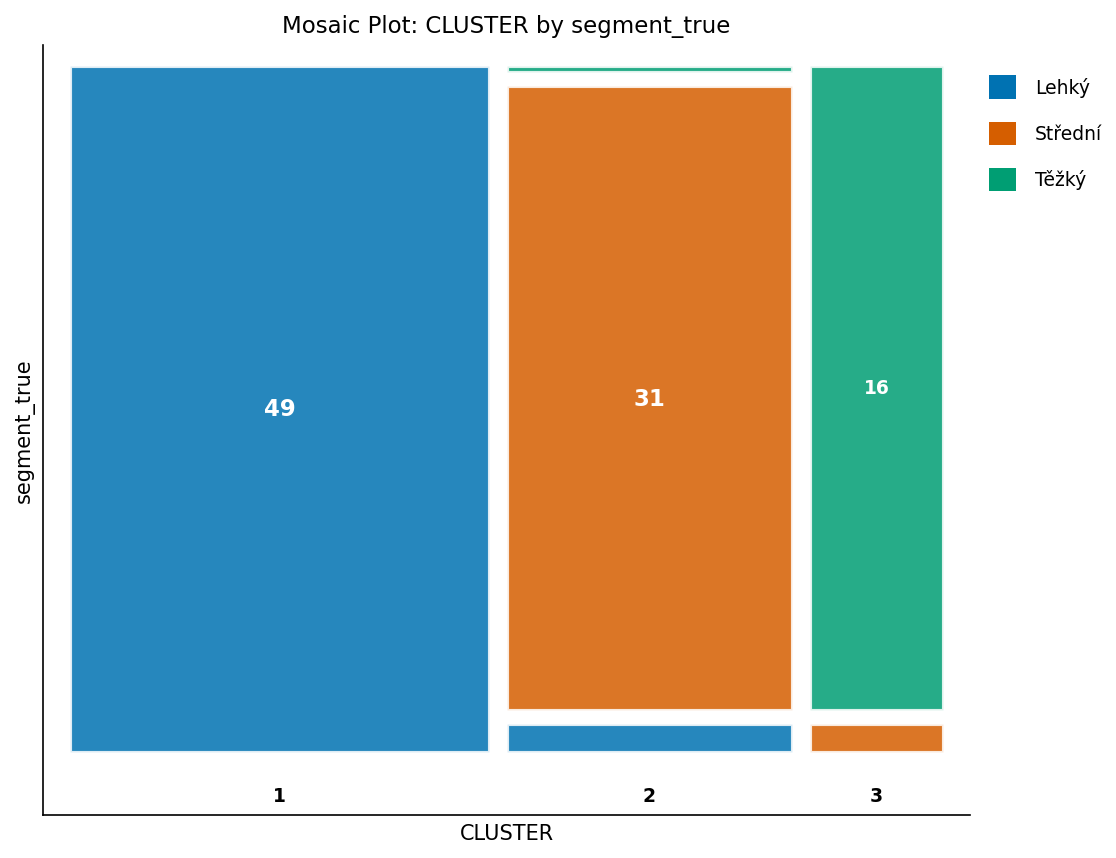

In [6]:
PROCEDURA ČETNOSTI data=scored;
   NÁZEV "Odhalený segment vs. vyloučená skutečná úroveň";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   ŠTÍTEK CLUSTER='Shluk' segment_true='Skutečná úroveň';
SPUSTIT;
NÁZEV;


## Interpretace výsledků

**Co FASTCLUS odhalil.** Počínaje jediným zprava zešikmeným sloupcem spotřeby bez štítků vysvětlilo tříshlukové řešení metodou k-průměrů **89,9 %** rozptylu v logaritmizované spotřebě (celkové R² = 0,899, pseudo-F = 431) a rozdělilo účastníky na segment **lehký** (průměr 3,1 GB, n = 49), segment **střední** (průměr 12,8 GB, n = 34) a segment **těžký** (průměr 45,4 GB, n = 17). Křížová tabulace proti vyloučenému `segment_true` odhalila navrženou strukturu téměř přesně - **96 ze 100** účastníků skončilo ve shluku odpovídajícím jejich generující úrovni (Lehký 49/49, Střední 31/34, Těžký 16/17).

**Proč logaritmické měřítko.** Spotřeba dat je striktně kladná a s těžkým chvostem; shlukování `log_gb` udržuje euklidovské vzdálenosti smysluplné a průměry segmentů dobře oddělené, zatímco exponenciální zpětná transformace reprodukuje realistickou zešikmenost na měřítku GB.

**Proč na tom operativně záleží.** Každý účastník opouští model s pevným segmentovým označením *a* skóre vzdálenosti od centroidu, takže operátor může jednat s kalibrovanou jistotou - sebevědomě cílit centrální náročné uživatele na prémiové tarify a označit hraniční zákazníky (velká vzdálenost) k bližšímu pohledu. Průměrná doba trvání se také liší napříč odhalenými segmenty, což je vodítko pro časování životního cyklu a upsellu.

**Volba počtu segmentů.** Porovnání `MAXCLUSTERS=` 2, 3 a 4 podle celkového R² a pseudo-F je transparentní, reprodukovatelný způsob, jak zvolit *k*: velký zisk u tří shluků a pouze kosmetický zisk u čtyř (které rozdělí lehkou úroveň) učinil ze tří shluků obhajitelnou volbu.

**Vztah k modelům konečné směsi.** Model konečné směsi (PROC HPFMM / PROC FMM) by přidal měkké posteriorní příslušnosti a na věrohodnosti založené BIC pro počet složek. Tyto procedury zatím nejsou v tomto sestavení numericky implementovány; PROC FASTCLUS dodává stejnou akceschopnou segmentaci - odhalení, charakterizaci, pevné přiřazení a míru důvěry - s plně numerickým, reprodukovatelným výstupem již dnes.
